# 02 · Data conversion

Converts the raw datasets into a paired layout Ultralytics can read: same-named visible and infrared images at 640 px, YOLO labels and three data YAMLs per dataset. Every choice is recorded in `dataset_card.json`.

| | |
|---|---|
| **Kaggle settings** | Accelerator **GPU T4 x2**, Internet **on** |
| **Inputs to attach** | `cffm-net-pilot`, raw LLVIP and M3FD |
| **Expected runtime** | about 5 minutes |
| **Produces** | `data/llvip/`, `data/m3fd/` (and, if you save a version, an attachable output) |

In [1]:
import glob, shutil, subprocess, sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    PROJECT = Path("/kaggle/working/cffm-net-pilot")
    if not PROJECT.exists():
        hits = [Path(p).parent for k in range(1, 6) for p in glob.glob("/kaggle/input" + "/*" * k + "/pyproject.toml")
                if (Path(p).parent / "src" / "cffm").is_dir()]
        hits.sort(key=lambda h: any((h.parent / d).exists() for d in ("runs", "data")))
        zips = [Path(p) for k in range(1, 5) for p in glob.glob("/kaggle/input" + "/*" * k + ".zip")
                if "cffm" in Path(p).name]
        if hits:
            shutil.copytree(hits[0], PROJECT, copy_function=shutil.copyfile)
        elif zips:
            shutil.unpack_archive(str(zips[0]), "/kaggle/working")
        assert PROJECT.exists(), "Add the 'cffm-net-pilot' dataset (the uploaded zip) as an input to this notebook."
        for p in [PROJECT, *PROJECT.rglob("*")]:
            p.chmod(p.stat().st_mode | 0o200)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.4.171",
                    "faster-coco-eval>=1.6.7", "cloudpickle", "pytest", "lap>=0.5.12", "imageio-ffmpeg"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(PROJECT)], check=True)
else:
    PROJECT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "cffm").is_dir())
sys.path.insert(0, str(PROJECT / "src"))

import cffm
from cffm import env as cenv, pipeline
print("cffm", cffm.__version__, "imported from", Path(cffm.__file__).parent)
env = cenv.setup()
plan = pipeline.load_plan(env.project)

cffm 0.1.0 imported from C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\src\cffm
platform=local  device=0  gpus=[NVIDIA GeForce RTX 4050 Laptop GPU (6 GB)]  scan=torch
project=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot
data=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed
runs=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs


## Convert

Options come from `configs/pilot.yaml`, so every notebook builds the identical dataset.

In [2]:
cards = {}
for name in ("llvip", "m3fd"):
    out = pipeline.prepare(name, env, plan, force=False)
    cards[name] = __import__("json").loads((out / "dataset_card.json").read_text())
    print(name, "->", out)

llvip -> C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed\llvip
m3fd -> C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed\m3fd


## What we made

The object-size bins show how small the objects are at training resolution.

In [3]:
import pandas as pd
rows = [{"dataset": n, "train": c["images"]["train"], "val (full)": c["images"]["val"], "objects": c["objects"],
         **c["object_size_bins"]} for n, c in cards.items()]
pd.DataFrame(rows).set_index("dataset")

,train,val (full),objects,<8px,8-16px,16-32px,32-96px,>96px
dataset,,,,,,,,
llvip,4009,3463,19807,0,3,121,17695,1988
m3fd,3360,840,34407,2540,8341,9483,11217,2826


In [4]:
print((env.data / "llvip" / "data_paired.yaml").read_text())

path: C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed\llvip
names:
  0: person
train: images/visible/train
val: val_mini_visible.txt
test: images/visible/val
channels: 4
paired: true



## Sanity checks

Every visible image has a same-size thermal partner and a label file, and every box lies inside the image.

In [5]:
import cv2, numpy as np
for name in ("llvip", "m3fd"):
    root = env.data / name
    for split in ("train", "val"):
        vis = sorted((root / "images" / "visible" / split).glob("*.jpg"))
        missing = [v for v in vis if not (root / "images" / "infrared" / split / v.name).exists()
                   or not (root / "labels" / "visible" / split / (v.stem + ".txt")).exists()]
        boxes = np.array([list(map(float, l.split()[1:])) for f in (root / "labels" / "visible" / split).glob("*.txt")
                          for l in f.read_text().splitlines() if l.strip()], dtype=float).reshape(-1, 4)
        inside = ((boxes[:, :2] - boxes[:, 2:] / 2 >= -1e-6) & (boxes[:, :2] + boxes[:, 2:] / 2 <= 1 + 1e-6)).all()
        size_ok = all(cv2.imread(str(v)).shape[:2] == cv2.imread(str(root / "images" / "infrared" / split / v.name)).shape[:2]
                      for v in vis[::25])
        print(f"{name} {split}: {len(vis)} pairs, {len(missing)} incomplete, {len(boxes)} boxes, "
              f"all inside image: {bool(inside)}, pair sizes match: {size_ok}")
        assert vis and not missing and inside and size_ok

llvip train: 4009 pairs, 0 incomplete, 11505 boxes, all inside image: True, pair sizes match: True


llvip val: 3463 pairs, 0 incomplete, 8302 boxes, all inside image: True, pair sizes match: True


m3fd train: 3360 pairs, 0 incomplete, 27575 boxes, all inside image: True, pair sizes match: True


m3fd val: 840 pairs, 0 incomplete, 6832 boxes, all inside image: True, pair sizes match: True


## Look at a few converted pairs, with their labels

A box beside the person in the thermal image means misregistration (notebook 03 measures it).

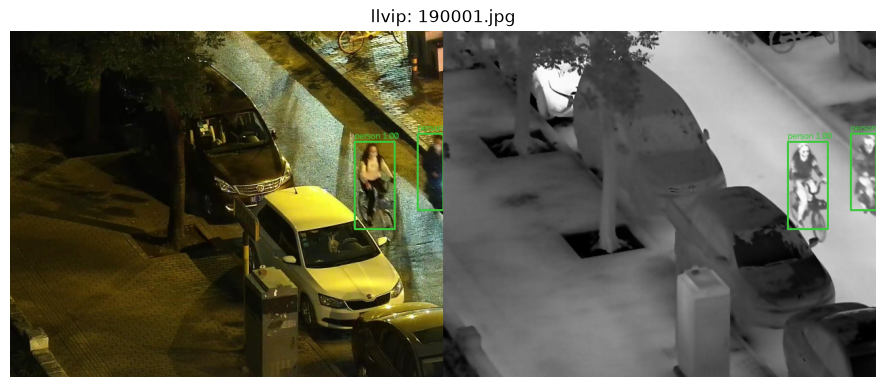

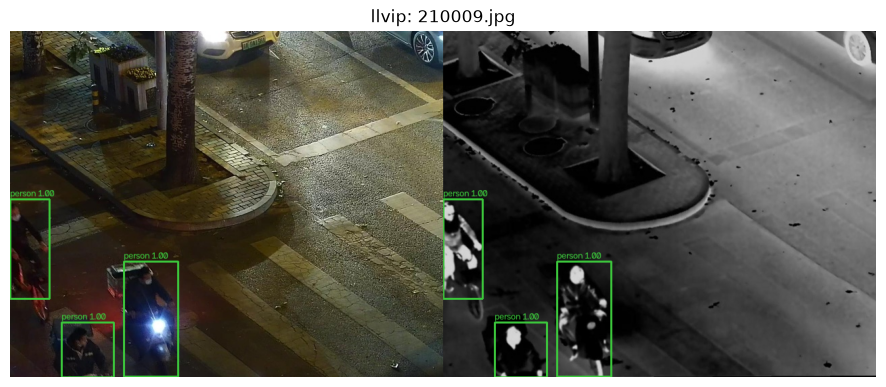

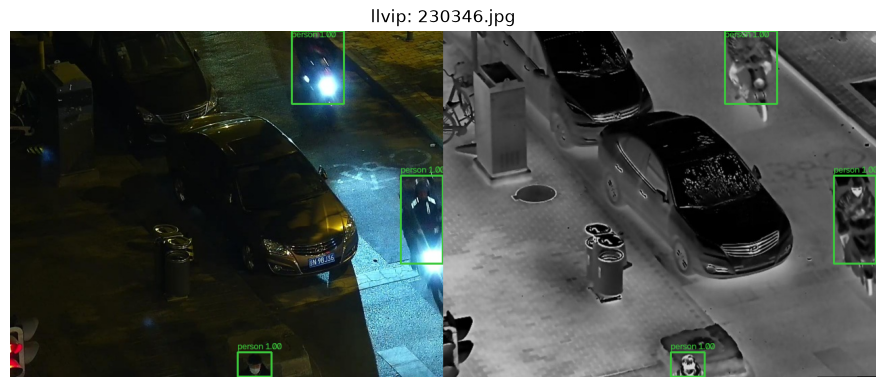

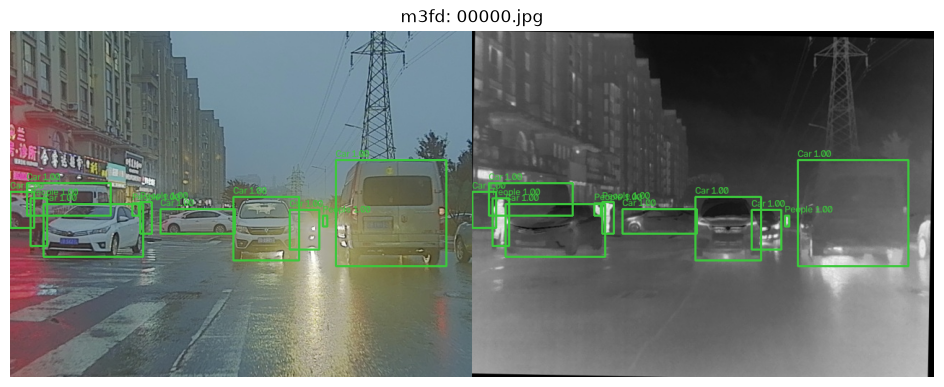

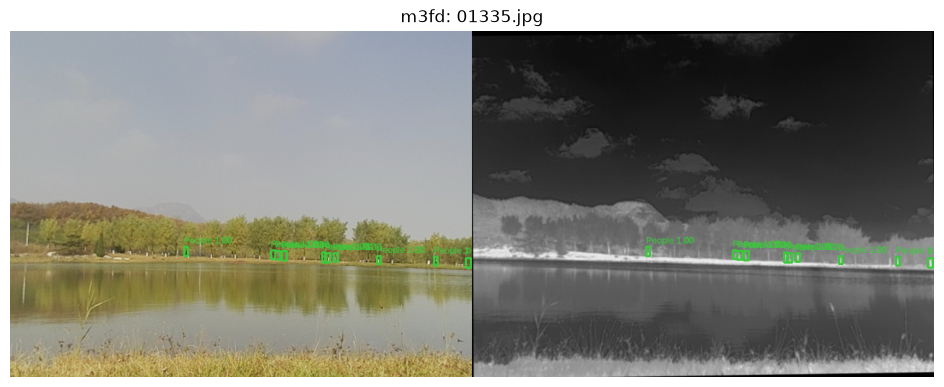

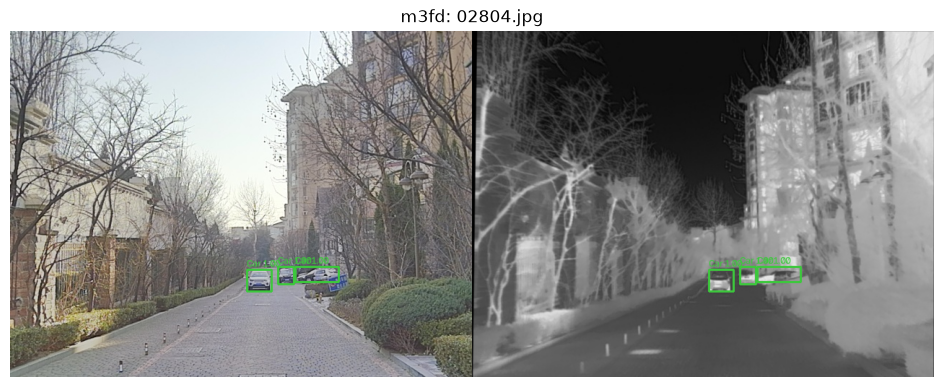

In [6]:
import matplotlib.pyplot as plt
from cffm.data import read_pair
from cffm.viz import draw_pair

def show(name, k=3):
    root = env.data / name
    vis = sorted((root / "images" / "visible" / "val").glob("*.jpg"))
    vis = vis[:: max(1, len(vis) // k)][:k]
    names = cards[name]["names"]
    for v in vis:
        pair = read_pair(str(v)); h, w = pair.shape[:2]
        gt = []
        for line in (root / "labels" / "visible" / "val" / (v.stem + ".txt")).read_text().splitlines():
            c, x, y, bw, bh = map(float, line.split())
            gt.append([(x - bw / 2) * w, (y - bh / 2) * h, (x + bw / 2) * w, (y + bh / 2) * h, 1.0, c])
        plt.figure(figsize=(14, 4.5)); plt.imshow(draw_pair(pair, gt, names)); plt.axis("off"); plt.title(f"{name}: {v.name}")
        plt.show()

show("llvip"); show("m3fd")

### Keep the results

On Kaggle, click **Save Version → Save & Run All (Commit)** so `runs/` becomes an output that notebooks **09**
and **15** can attach (*Add Input → Your Work → this notebook*). Without a saved version the checkpoints vanish.